<img src='loan.png' width='90%' height='600px' align='center' />

# MACHINE LEARNING MODEL FOR LOAN APPROVAL

## Overview

### Bottom Line Up Front (BLUF)

This project developed a machine learning classification model to support FinTech Innovations' loan approval process. The objective was to improve the speed and consistency of loan decisions while accounting for the unequal financial consequences of incorrect decisions. Under the business assumptions provided, a false positive, representing an incorrectly approved loan, carries an estimated cost of **$50,000**, while a false negative, representing an incorrectly denied creditworthy applicant, carries an estimated cost of **$8,000**. Therefore, false positives are 6.25 times more costly than false negatives.

The analysis followed the CRISP-DM framework, covering business understanding, data understanding, data preparation, modeling, evaluation, and recommendations. The dataset contained **20,000 loan applications**, with approximately **24% approved and 76% not approved**. Three classification models were evaluated: Logistic Regression, Decision Tree, and Random Forest. The Random Forest model was selected for hyperparameter tuning because it can capture nonlinear relationships and interactions between applicant characteristics.

After hyperparameter tuning using **GridSearchCV with 5-fold cross-validation**, the selected Random Forest model used 200 trees, a maximum depth of 20, a minimum of 5 samples required for a split, and a minimum of 1 sample required at a leaf node.

On the held-out test set, the tuned model achieved **99.05% accuracy, 98.52% precision, 97.49% recall, and a 99.94% ROC-AUC**. The model produced **14 false positives and 24 false negatives**. Using the business cost assumptions, this resulted in an estimated total business cost of **$892,000**, calculated as:

**(14 × $50,000) + (24 × $8,000) = $892,000**

The model's feature importance analysis showed that `RiskScore` was the dominant predictor, accounting for approximately **45.75%** of the Random Forest's total feature importance. Other important features included `TotalDebtToIncomeRatio` (12.93%), `MonthlyIncome` (10.03%), and `AnnualIncome` (9.81%). These findings are consistent with the correlation analysis, where `RiskScore` had the strongest relationship with loan approval (r = -0.766), while `MonthlyIncome` and `AnnualIncome` had positive correlations of 0.604 and 0.598 respectively.

Although the model demonstrated very strong predictive performance, the results require additional validation before deployment. In particular, the unusually high ROC-AUC and the dominant importance of `RiskScore` require investigation to confirm that the feature is based only on information available at the time of application and does not contain information derived from the approval decision or subsequent loan outcomes.

The model also showed some differences in performance across applicant segments. Recall was **90.24% for self-employed applicants**, compared with 98.18% for employed applicants and 98.00% for unemployed applicants. Applicants with a recorded bankruptcy history had **82.14% recall**, compared with 97.95% for applicants without a bankruptcy history. These differences do not by themselves establish model bias, but they indicate areas that should be monitored and investigated through additional fairness and performance analysis.

Overall, the Random Forest shows strong potential as a **decision-support tool** for loan officers. Before production deployment, FinTech Innovations should validate the data and feature definitions, particularly `RiskScore`, confirm the business cost assumptions using real financial outcomes, evaluate alternative classification thresholds, and establish ongoing monitoring for model performance and segment-level differences.


## Business Understanding

### Business Problem

FinTech Innovations currently relies heavily on manual review by loan officers when evaluating loan applications. Although human review allows loan officers to consider applicant circumstances, a heavily manual process can be time-consuming and may result in inconsistent decisions across applicants. The company wants to introduce a data-driven approach that can support faster and more consistent loan decisions while maintaining appropriate controls around financial risk.

The available dataset contains **20,000 loan applications** and includes information about applicants' financial circumstances, credit behavior, employment, assets, liabilities, and previous loan performance. The target variable, `LoanApproved`, is binary, with approximately **24% of applications approved and 76% not approved**.

The objective of this project is to develop a classification model that can support the loan approval process while explicitly considering the financial consequences of incorrect predictions.

### Key Stakeholders

Several stakeholders are affected by the loan approval process:

* **Loan officers:** Need a model that provides consistent and interpretable information to support application reviews without completely replacing professional judgment.

* **Risk management team:** Needs to manage financial exposure and reduce the number of costly incorrect approvals.

* **Company management:** Needs an efficient approval process that balances loan profitability, operational efficiency, and financial risk.

* **Applicants:** Need timely and consistent decisions and should not be unnecessarily denied access to credit.

* **Data science and technology teams:** Need a model that can be reliably implemented, monitored, and maintained while minimizing data leakage and other sources of model risk.

The needs of these stakeholders create a trade-off between reducing financial losses from incorrect approvals and avoiding unnecessary rejection of potentially creditworthy applicants.

### Business Impact of Model Errors

The business assigns different financial consequences to the two types of classification errors.

A **false positive** occurs when the model predicts that an application should be approved when the actual outcome in the historical data is not approved. For the purposes of this exercise, a false positive is interpreted as an incorrectly approved loan that subsequently defaults, with an estimated financial cost of **$50,000 per case**.

A **false negative** occurs when the model predicts that an application should not be approved when the historical outcome is approved. For the purposes of this exercise, this represents an incorrectly denied creditworthy applicant, with an estimated lost profit of **$8,000 per case**.

Therefore:

* False Positive Cost = **$50,000**
* False Negative Cost = **$8,000**

The cost ratio is:

$$
\frac{50,000}{8,000} = 6.25
$$

Therefore, under the assumptions provided, a false positive is **6.25 times more costly** than a false negative.

This cost asymmetry means that accuracy alone is not sufficient for evaluating the model. A model can achieve high overall accuracy while still generating a financially undesirable number of false positives.

The final tuned Random Forest produced **14 false positives and 24 false negatives** on the held-out test set. Using the defined costs, the estimated business cost was:

$$
(14 \times 50,000) + (24 \times 8,000) = \$892,000
$$

This represents the estimated cost under the lab's assumptions rather than an observed financial loss. In a real deployment, these cost estimates should be validated against actual default losses, recovery rates, and lost-profit data.

### Classification vs. Regression

Two possible approaches were considered.

A **regression approach** could be used to predict a continuous value, such as an estimated probability of default or expected financial loss. This could provide a risk score that the business could use to establish its own approval thresholds.

A **classification approach** directly predicts a discrete outcome, such as whether an application is approved or not approved.

For this project, classification was selected as the primary approach because the historical dataset contains a binary `LoanApproved` outcome and the business problem is fundamentally concerned with supporting an approval decision. Classification also provides predicted probabilities, which can be evaluated at different decision thresholds.

The classification approach therefore provides both a direct decision and the flexibility to examine probability thresholds. This is particularly useful because the financial costs of false positives and false negatives are asymmetric.

The final model should be viewed as a **decision-support tool rather than an unconditional replacement for human review**, particularly for borderline applications.

---

## Modeling Goals and Success Criteria

The primary modeling goal is to develop a classification model that can distinguish between approved and non-approved loan applications while minimizing financially costly prediction errors.

The model was evaluated using multiple metrics because no single metric fully captures both predictive performance and business impact.

### Precision

Precision measures the proportion of applications predicted as approved that were actually approved in the historical data.

Precision is particularly relevant because false positives represent the more costly error under the business assumptions.

The tuned Random Forest achieved a **precision of 98.52%** on the held-out test set.

### Recall

Recall measures the proportion of actually approved applications that the model correctly identified as approved.

Recall is important because low recall would mean that more potentially creditworthy applicants are incorrectly classified as not approved.

The tuned Random Forest achieved a **recall of 97.49%** on the held-out test set.

### ROC-AUC

ROC-AUC measures the model's ability to distinguish between the two classes across different classification thresholds.

This metric was particularly useful for comparing models and selecting hyperparameters because it evaluates ranking performance independently of a single classification threshold.

The tuned Random Forest achieved a **ROC-AUC of 99.94%** on the held-out test set.

### Business Cost

A custom business-cost metric was created to translate classification errors into estimated financial consequences:

$$
\text{Business Cost} =
(\text{FP} \times \$50,000) +
(\text{FN} \times \$8,000)
$$

For the final model:

$$
(14 \times \$50,000) + (24 \times \$8,000)
= \$892,000
$$

Lower business cost represents fewer estimated financial consequences under the assumptions provided by the business.

### Accuracy

Accuracy was also reported as a descriptive metric. The tuned Random Forest achieved **99.05% accuracy** on the held-out test set.

However, accuracy was not used as the sole model-selection criterion because approximately 76% of applications belonged to the non-approved class and because the two types of errors have substantially different financial consequences.

### Baseline Performance

The target variable was imbalanced, with approximately **76% of applications not approved and 24% approved**.

A majority-class baseline is therefore useful for understanding how much predictive value the machine learning models provide beyond simply predicting the most common class.

The majority-class baseline would achieve approximately **76% accuracy** by predicting every application as not approved. However, this strategy would fail to identify approved applications and would therefore have extremely poor recall for the approved class.

The final Random Forest achieved **99.05% accuracy, 98.52% precision, 97.49% recall, and 99.94% ROC-AUC**, demonstrating substantially stronger predictive performance than a simple majority-class strategy.

The baseline is therefore useful as a reference point, but model selection was based on the combination of predictive metrics and the business-cost framework rather than accuracy alone.

### Overall Success Criteria

The project considered the model successful when it demonstrated:

1. Strong discrimination between approved and non-approved applications.
2. High precision to limit costly false positives.
3. High recall to reduce incorrect rejection of approved applicants.
4. Low estimated business cost under the defined financial assumptions.
5. Stable performance during cross-validation.
6. Reasonable performance across applicant segments.
7. No obvious data leakage or use of information that would be unavailable at the time of application.

The final model met the predictive performance criteria on the available test data. However, the unusually high performance and the dominant contribution of `RiskScore` indicate that additional validation is required before the model could be considered for production deployment.


In [4]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report)

In [5]:
# Load the dataset
df = pd.read_csv("financial_loan_data.csv")

# Display the first five rows
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [6]:
df.info() , df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

(None,
                 Age   CreditScore    Experience     LoanAmount  LoanDuration  \
 count  20000.000000  20000.000000  20000.000000   20000.000000  20000.000000   
 mean      39.752600    571.612400     17.522750   24882.867800     54.057000   
 std       11.622713     50.997358     11.316836   13427.421217     24.664857   
 min       18.000000    343.000000      0.000000    3674.000000     12.000000   
 25%       32.000000    540.000000      9.000000   15575.000000     36.000000   
 50%       40.000000    578.000000     17.000000   21914.500000     48.000000   
 75%       48.000000    609.000000     25.000000   30835.000000     72.000000   
 max       80.000000    712.000000     61.000000  184732.000000    120.000000   
 
        NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
 count        20000.000000         20000.000000               20000.000000   
 mean             1.517300           454.292700                   0.286381   
 std              1.386325  

In [7]:
df.describe(include="object") #categorical variables

,AnnualIncome,EmploymentStatus,EducationLevel,MaritalStatus,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose
count,20000,20000,19099,18669,20000,20000,20000
unique,17516,3,5,4,4,2,5
top,"$15,000.00",Employed,Bachelor,Married,Mortgage,No,Home
freq,584,17036,5804,9370,7939,18952,5925


In [8]:
# Check dataset dimensions
print("Shape:", df.shape)

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Shape: (20000, 35)
Duplicate rows: 0


MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

In [9]:
# EDA Code Here - Create New Cells As Needed
# Target distribution
target_counts = df["LoanApproved"].value_counts()
target_percentages = df["LoanApproved"].value_counts(normalize=True) * 100

print("Loan Approval Counts:")
print(target_counts)

print("\nLoan Approval Percentages:")
print(target_percentages.round(2))

Loan Approval Counts:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Loan Approval Percentages:
LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64


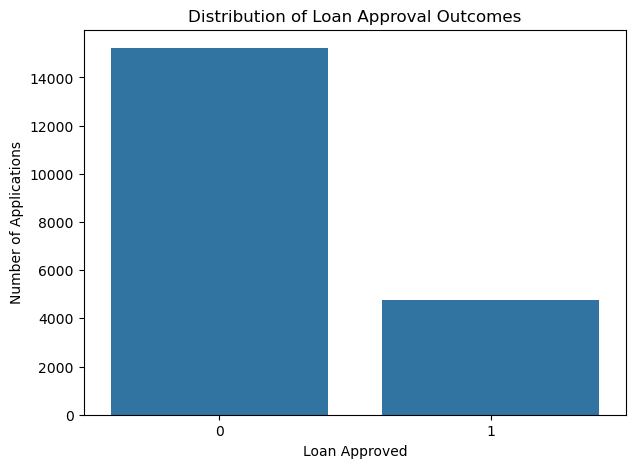

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="LoanApproved")

plt.title("Distribution of Loan Approval Outcomes")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")

plt.show()

### Target Distribution Interpretation

The target variable is imbalanced, with the non-approved class representing the majority of observations. This imbalance is important when evaluating model performance because a model can achieve relatively high accuracy by favoring the majority class while performing poorly at identifying approved applications.

For this reason, precision, recall, ROC-AUC, and the business-cost metric will be considered alongside accuracy.

In [11]:
# Identify numerical and categorical columns
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Categorical features:
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


In [12]:
numeric_features = [
    col for col in numeric_features
    if col != "LoanApproved"
]

categorical_features = [
    col for col in categorical_features
    if col != "LoanApproved"
]

In [13]:
# Calculate missing values
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing_values = (
    missing_values[missing_values["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

missing_values

,Missing_Count,Missing_Percentage
MaritalStatus,1331,6.655
EducationLevel,901,4.505
SavingsAccountBalance,572,2.860


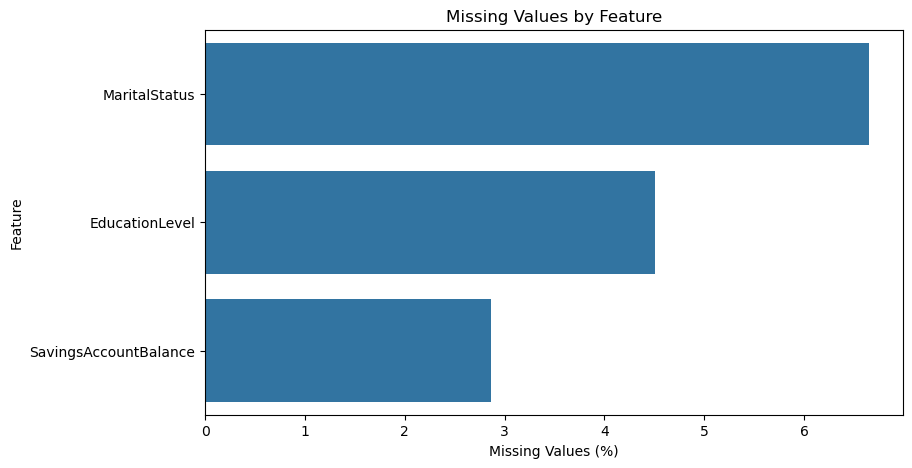

In [14]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=missing_values.reset_index(),
    x="Missing_Percentage",
    y="index"
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.show()

### Missing Value Findings

Missing values are concentrated in `MaritalStatus`, `EducationLevel`, and `SavingsAccountBalance`. These missing values need to be handled before modeling.

The missing categorical values will require an appropriate categorical imputation strategy, while the numerical `SavingsAccountBalance` variable will require numerical imputation.

Importantly, imputation will be performed within the machine learning pipeline rather than before the train-test split. This prevents information from the test set from influencing the preprocessing process.

### Data Quality: Annual Income

`AnnualIncome` represents a numerical financial variable but is stored as a string containing currency symbols and formatting characters. This prevents standard numerical analysis and machine learning algorithms from treating it as a continuous variable.

The variable will therefore be converted into a numeric format during data preparation.

In [15]:
df.dtypes

Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [16]:
# Inspect AnnualIncome before cleaning
df["AnnualIncome"].head(10)

0     $39,948.00
1     $39,709.00
2     $40,724.00
3     $69,084.00
4    $103,264.00
5    $178,310.00
6     $51,250.00
7     $97,345.00
8    $116,841.00
9     $40,615.00
Name: AnnualIncome, dtype: object

In [17]:
# Convert AnnualIncome from currency-formatted text to numeric
df["AnnualIncome"] = (
    df["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["AnnualIncome"].head()

0     39948.0
1     39709.0
2     40724.0
3     69084.0
4    103264.0
Name: AnnualIncome, dtype: float64

In [18]:
df.dtypes

Age                             int64
AnnualIncome                  float64
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [19]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features = [col for col in numeric_features if col != "LoanApproved"]
categorical_features = [col for col in categorical_features if col != "LoanApproved"]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']

Categorical features:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


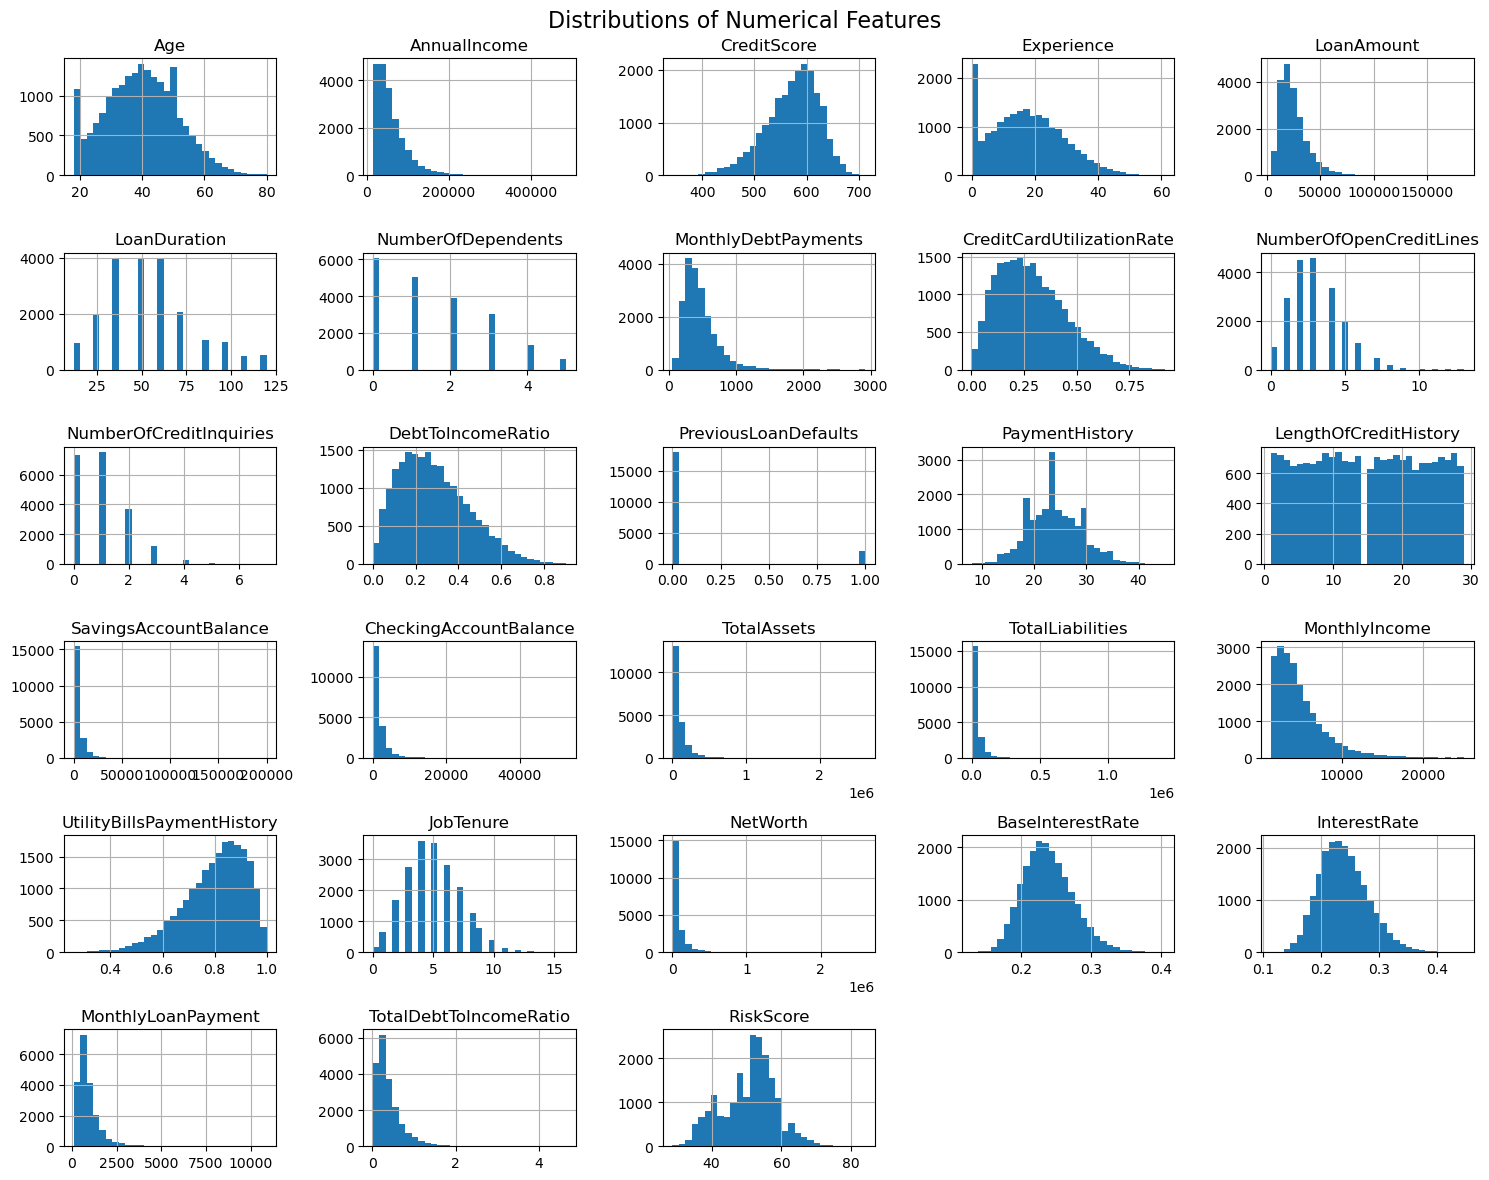

In [20]:
df[numeric_features].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

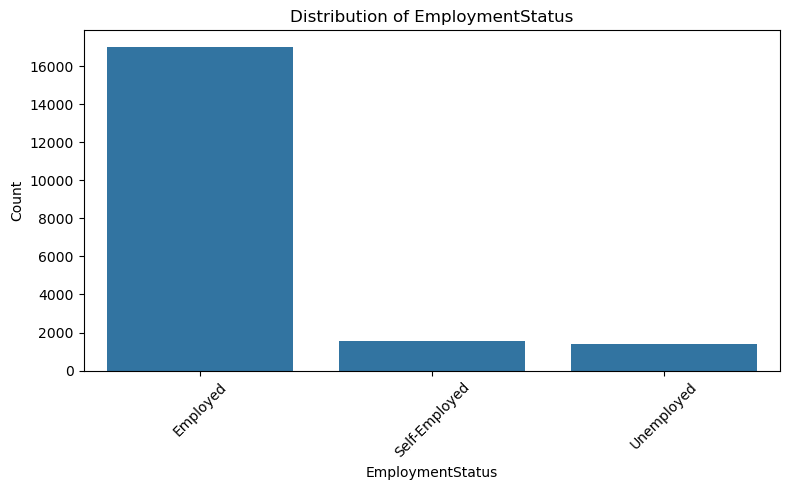

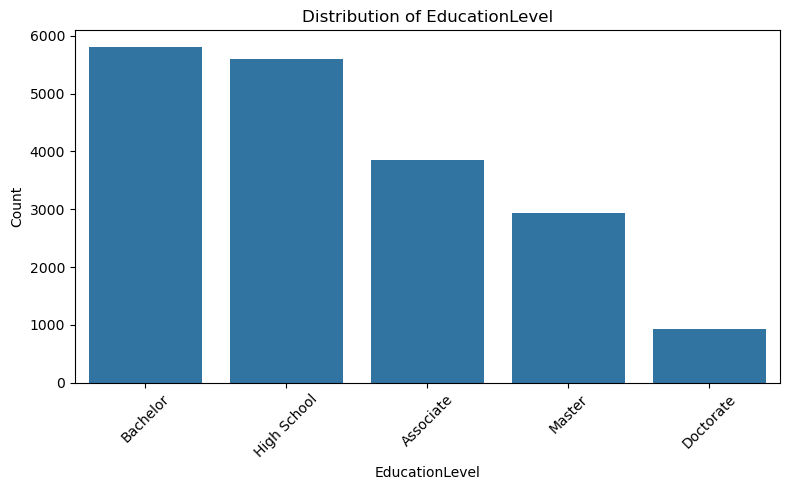

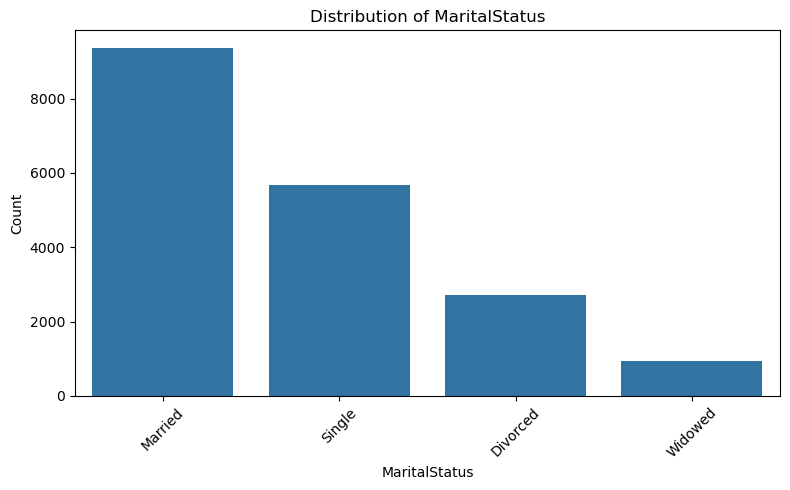

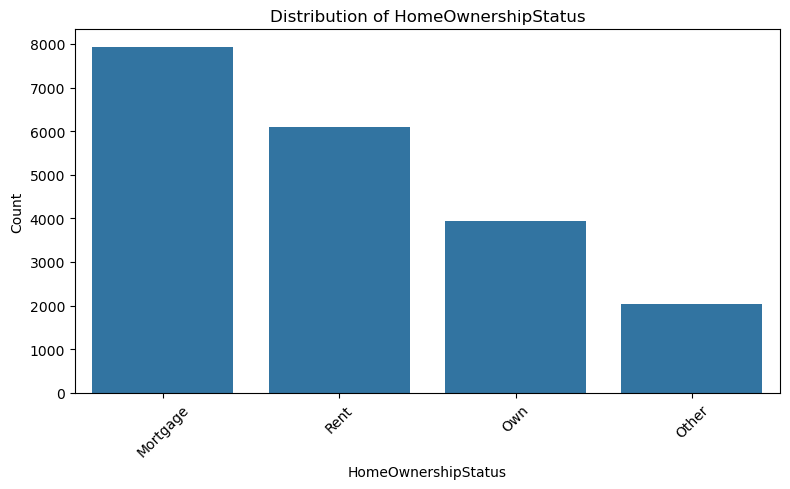

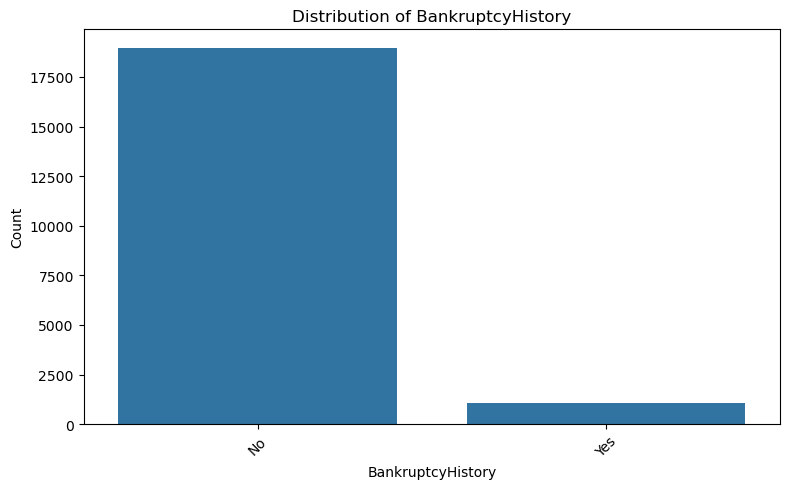

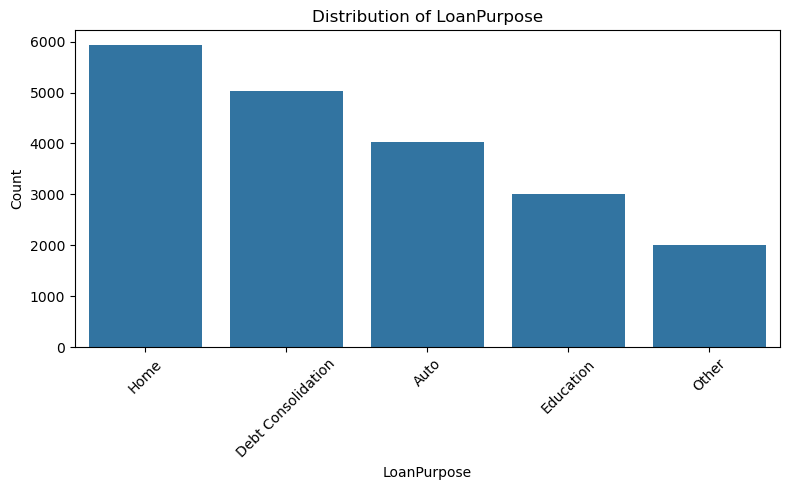

In [21]:
for col in categorical_features:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [22]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     9370
Single      5665
Divorced    2704
Widowed      930
Name: count, dtype: int64

HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

BankruptcyHistory
BankruptcyHistory
No     18952
Yes     1048
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


In [23]:
df.groupby("LoanApproved")[numeric_features].median().T

LoanApproved,0,1
Age,39.000000,42.000000
AnnualIncome,40557.500000,91269.500000
CreditScore,574.000000,591.000000
Experience,16.000000,20.000000
LoanAmount,23566.000000,17336.500000
LoanDuration,48.000000,48.000000
NumberOfDependents,1.000000,1.000000
MonthlyDebtPayments,409.000000,380.000000
CreditCardUtilizationRate,0.267819,0.261464
NumberOfOpenCreditLines,3.000000,3.000000


Approved applicants had higher median income, lower Risk Score and total debt to income ratio than non-approved applicants.

In [24]:
df[["RiskScore", "LoanApproved"]].groupby("LoanApproved").describe()

RiskScore                                                   
                 count       mean       std   min   25%   50%   75%   max
LoanApproved                                                             
0              15220.0  54.106307  5.301985  38.0  50.0  54.0  57.0  84.0
1               4780.0  40.133389  3.879725  28.8  37.6  40.0  42.4  56.0

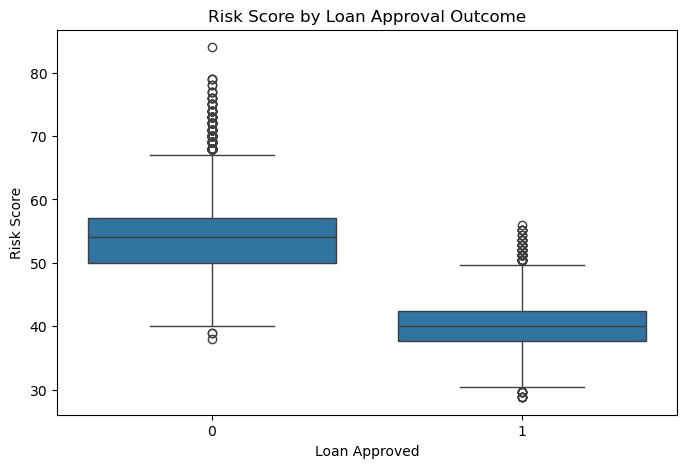

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="RiskScore"
)

plt.title("Risk Score by Loan Approval Outcome")
plt.xlabel("Loan Approved")
plt.ylabel("Risk Score")

plt.show()

In [26]:
df[["RiskScore", "LoanApproved"]].corr()

,RiskScore,LoanApproved
RiskScore,1.000000,-0.766137
LoanApproved,-0.766137,1.000000


RiskScore shows a strong relationship with LoanApproved, with approved applicants having substantially lower risk scores than non-approved applicants. Because the relationship is unusually strong, RiskScore requires a leakage investigation before it is included in the predictive model. Its use will depend on whether the score was available at the time of the loan application and whether it was calculated independently of the approval outcome or subsequent payment behavior.

In [27]:
# Correlation of numerical variables with LoanApproved

correlation_with_target = (
    df[numeric_features + ["LoanApproved"]]
    .corr()["LoanApproved"]
    .drop("LoanApproved")
    .sort_values(key=abs, ascending=False)
)

correlation_with_target

RiskScore                    -0.766137
MonthlyIncome                 0.604101
AnnualIncome                  0.597900
TotalDebtToIncomeRatio       -0.410399
InterestRate                 -0.301646
BaseInterestRate             -0.247263
LoanAmount                   -0.239496
NetWorth                      0.187892
MonthlyLoanPayment           -0.184272
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
LoanDuration                 -0.094558
MonthlyDebtPayments          -0.070415
PreviousLoanDefaults         -0.065343
PaymentHistory                0.030804
TotalLiabilities             -0.029434
CreditCardUtilizationRate    -0.010466
NumberOfCreditInquiries      -0.005885
JobTenure                     0.004997
NumberOfOpenCreditLines      -0.004769
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
CheckingAccountBalance   

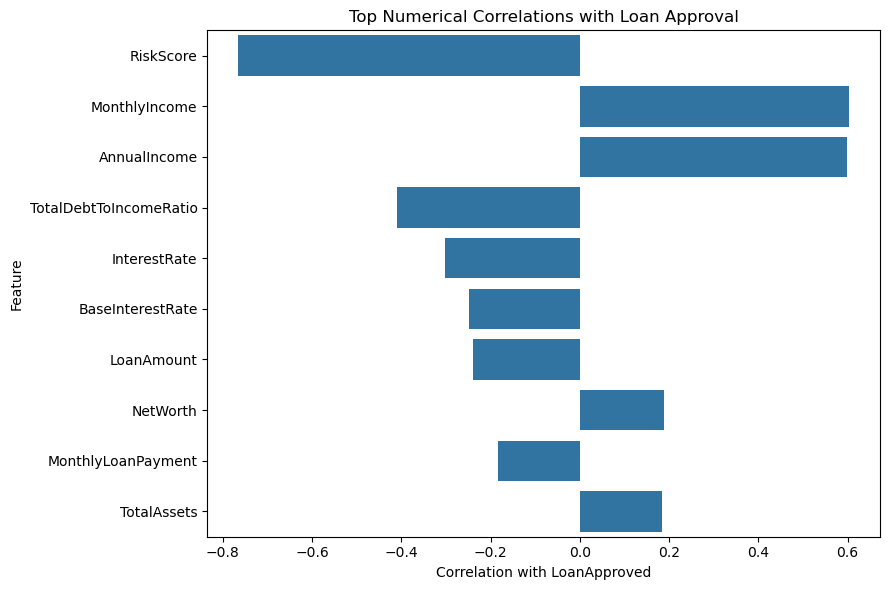

In [34]:
top_correlations = correlation_with_target.head(10)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.title("Top Numerical Correlations with Loan Approval")
plt.xlabel("Correlation with LoanApproved")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Correlation Findings

The correlation analysis shows that several numerical variables have notable relationships with loan approval. `RiskScore` has the strongest relationship with `LoanApproved` (r = -0.766), indicating that higher risk scores are strongly associated with lower approval rates. `MonthlyIncome` (r = 0.604) and `AnnualIncome` (r = 0.598) show strong positive relationships with approval, while `TotalDebtToIncomeRatio` (r = -0.410) shows a moderate negative relationship.

`InterestRate`, `BaseInterestRate`, and `LoanAmount` also show moderate negative relationships with loan approval. In contrast, variables such as `DebtToIncomeRatio`, `SavingsAccountBalance`, and `CheckingAccountBalance` have correlations close to zero.

These correlations describe associations rather than causation. In addition, the unusually strong relationship between `RiskScore` and the target requires further investigation to determine whether the variable was available at the time of application and whether it contains information derived from the approval decision or subsequent payment behavior. Similar timing considerations should be investigated for interest-rate and loan-payment variables before final feature selection.

In [28]:
approval_rates = []

for col in categorical_features:
    rates = df.groupby(col)["LoanApproved"].mean().reset_index()
    rates.columns = ["Category", "ApprovalRate"]
    rates["Feature"] = col
    approval_rates.append(rates)

approval_rates_df = pd.concat(approval_rates, ignore_index=True)

approval_rates_df = approval_rates_df[
    ["Feature", "Category", "ApprovalRate"]
]

approval_rates_df

,Feature,Category,ApprovalRate
0,EmploymentStatus,Employed,0.240021
1,EmploymentStatus,Self-Employed,0.278449
2,EmploymentStatus,Unemployed,0.181884
3,EducationLevel,Associate,0.214026
4,EducationLevel,Bachelor,0.277912
5,EducationLevel,Doctorate,0.456522
6,EducationLevel,High School,0.152539
7,EducationLevel,Master,0.364814
8,MaritalStatus,Divorced,0.244822
9,MaritalStatus,Married,0.237033


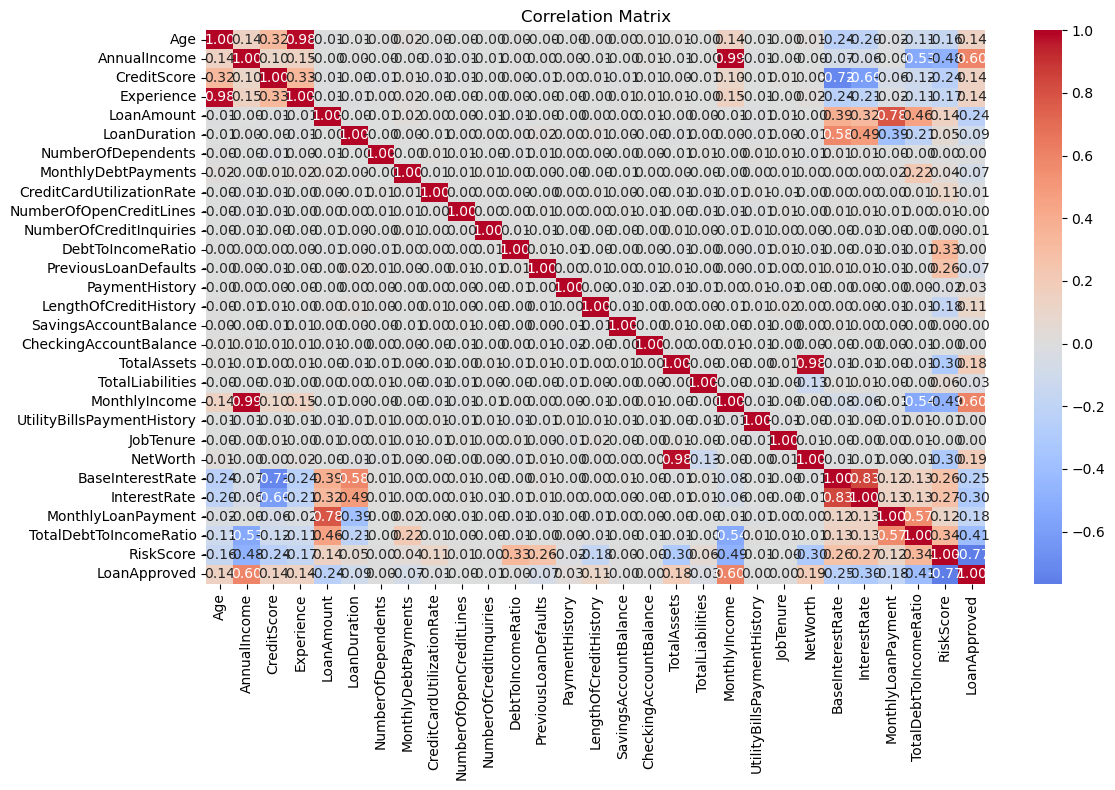

In [29]:
correlation = df[numeric_features + ["LoanApproved"]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [30]:
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df["LoanApproved"].value_counts(normalize=True))

Duplicate rows: 0

Missing values:
EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64

Data types:
Age                             int64
AnnualIncome                  float64
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccou

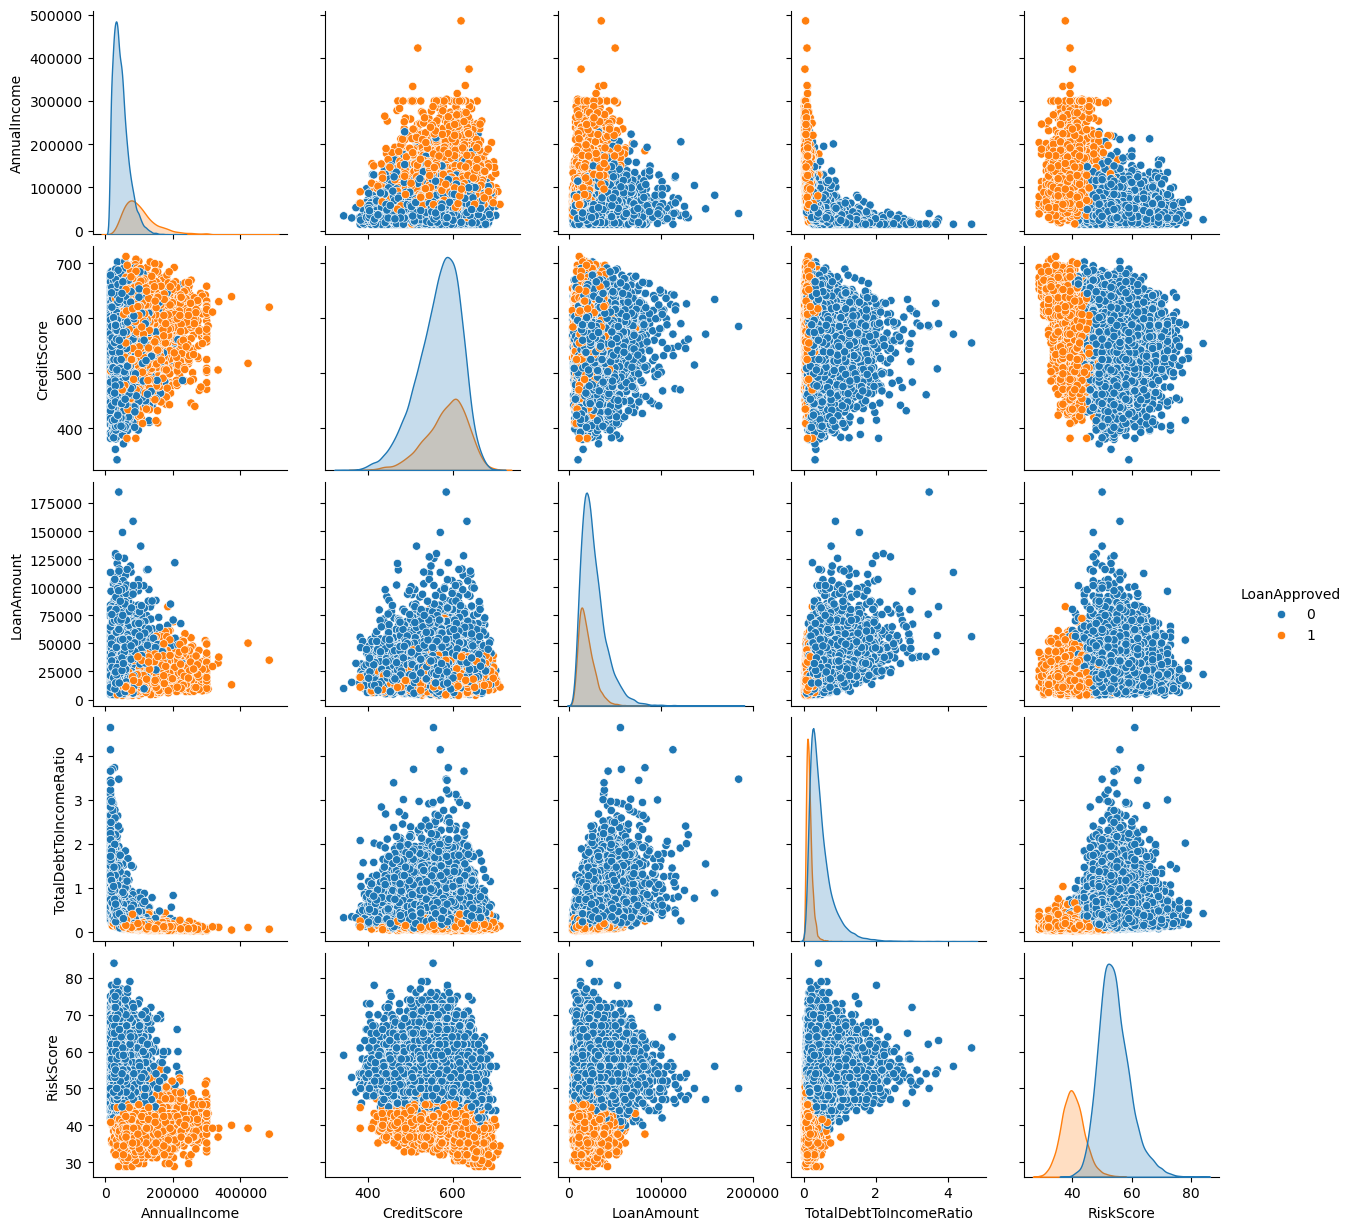

In [35]:
pairplot_features = [
    "AnnualIncome",
    "CreditScore",
    "LoanAmount",
    "TotalDebtToIncomeRatio",
    "RiskScore",
    "LoanApproved"
]

sns.pairplot(
    df[pairplot_features],
    hue="LoanApproved"
)

plt.show()

### Pairplot Findings

The pairplot provides visual evidence of differences between approved and non-approved loan applications. `RiskScore` shows the clearest separation between the two target classes, with approved applications concentrated at lower risk scores and non-approved applications concentrated at higher risk scores. `TotalDebtToIncomeRatio` also shows substantial differences between the groups, with non-approved applications more frequently associated with higher debt-to-income ratios.

`LoanAmount` shows that approved applications are more concentrated at lower requested loan amounts, while non-approved applications include a wider range of larger loan amounts. `AnnualIncome` and `CreditScore` show greater overlap between the two classes, indicating that these variables do not separate the target classes as clearly on their own.

These visual patterns are consistent with the correlation analysis, but they represent associations rather than causal relationships. The strong separation associated with `RiskScore` also reinforces the need to investigate whether this variable was available at the time of the original loan decision or contains information derived from the decision or subsequent repayment behavior.

# Potential data quality issues and their implication

- Missing values: Missing values were identified in MaritalStatus (1,331 records), EducationLevel (901 records), and SavingsAccountBalance (572 records). These missing values will be handled during preprocessing using appropriate imputation methods.
- Incorrect data type: AnnualIncome was initially stored as a text/object variable because values contained dollar signs and commas. The formatting characters were removed and the variable was converted to a numerical data type.
- Duplicate records: No duplicate rows were identified, so no duplicate records needed to be removed.
- Target imbalance: LoanApproved is imbalanced, with substantially more non-approved than approved applications. Therefore, accuracy alone will not be sufficient for evaluating the models, and precision, recall, ROC-AUC, and business cost will also be considered.


# FEATURE UNDERSTANDING

## Categorize features

- Numerical: Age, AnnualIncome, CreditScore, Experience, LoanAmount, LoanDuration, NumberOfDependents, MonthlyDebtPayments, CreditCardUtilizationRate, NumberOfOpenCreditLines, NumberOfCreditInquiries, DebtToIncomeRatio, PreviousLoanDefaults, PaymentHistory, LengthOfCreditHistory, SavingsAccountBalance, CheckingAccountBalance, TotalAssets, TotalLiabilities, MonthlyIncome, UtilityBillsPaymentHistory, JobTenure, NetWorth, BaseInterestRate, InterestRate, MonthlyLoanPayment, TotalDebtToIncomeRatio, RiskScore.

- Categorical nominal: EmploymentStatus, MaritalStatus, HomeOwnershipStatus, BankruptcyHistory, LoanPurpose.

- Categorical ordinal: EducationLevel.

- Target: LoanApproved.


## Special preprocessing
Numerical features
- Need missing-value imputation where applicable
- Need scaling for Logistic Regression

Categorical nominal features

- Need missing-value imputation
- Need One-Hot Encoding

Ordinal feature

- EducationLevel
    Has an inherent order, so we need to decide how to represent it during preprocessing

- AnnualIncome

    Already done cleaning because of $ and commas

Missing values

- MaritalStatus: 1,331
EducationLevel: 901
SavingsAccountBalance: 572

- Missing values may indicate that some applicant information was not collected, was unavailable, or was not reported. Because the reason for missingness is not known from the dataset, the values should be handled carefully rather than automatically interpreted as zero or absence of the characteristic.


## Possible feature engineering opportunities

- Income-to-loan ratio: compare AnnualIncome with LoanAmount
- Debt burden: combine income and liability information
- Asset-to-liability ratio: capture overall financial strength
- Loan-to-income ratio: assess whether the requested loan is large relative to income
- Credit utilization and credit history: potentially combine credit behavior indicators

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [37]:
# Data Prep Code Here - Create New Cells As Needed
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 34)
y shape: (20000,)


In [38]:
numeric_features = [
    col for col in X.select_dtypes(include=["int64", "float64"]).columns
]

categorical_features = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]

ordinal_features = [
    "EducationLevel"
]

print("Numerical:", numeric_features)
print("\nCategorical:", categorical_features)
print("\nOrdinal:", ordinal_features)

Numerical: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']

Categorical: ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

Ordinal: ['EducationLevel']


In [39]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [42]:
categorical_features = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### Handling Missing Values

Missing values were identified during the EDA phase, but they are handled during the data preparation stage.

The dataset contains missing values in `MaritalStatus`, `EducationLevel`, and `SavingsAccountBalance`. Instead of manually filling these values in the original dataset, imputation is included within the preprocessing pipelines.

- **Numerical features:** Missing values are replaced using the median. The median is less affected by extreme values than the mean.
- **Categorical and ordinal features:** Missing values are replaced using the most frequent category, which preserves the categorical nature of the variables.

Missing-value imputation is performed inside the `Pipeline` and `ColumnTransformer`. This ensures that the imputation values are learned only from the training data and then applied to the test data. This approach helps prevent data leakage and ensures that the test set remains unseen during model training.

### Categorical and Ordinal Features

Categorical and ordinal features are processed together because both contain categorical values that must be converted into numerical representations for machine learning.

Although `EducationLevel` is ordinal, it is treated as categorical and one-hot encoded. This avoids assuming equal spacing between education levels. Missing categorical values are replaced with the most frequent category, then the categories are converted into numerical features using `OneHotEncoder`.

In [43]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


- Numerical variables will use median imputation to handle missing values while reducing sensitivity to extreme values.
- Numerical variables will be standardized using StandardScaler, which is appropriate for Logistic Regression.
- Categorical variables will use most-frequent imputation for missing values.
- Categorical variables, including the ordinal EducationLevel, will be one-hot encoded to convert categories into numerical representations without imposing equal numerical distances between categories.
- ColumnTransformer will apply the appropriate preprocessing to each feature type.
- Pipeline will combine preprocessing steps and later the model, helping prevent data leakage by fitting preprocessing only on the training data.
- FeatureUnion is not necessary because ColumnTransformer already allows us to apply different transformations to different feature groups and combine their outputs.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


### Model Selection

Three classification algorithms were selected to provide a comparison between a simple linear model and tree-based models.

- **Logistic Regression:** Used as an interpretable baseline for binary classification. It estimates the probability of loan approval and provides a useful benchmark for more complex models.
- **Decision Tree:** Selected because it can capture nonlinear relationships and interactions between applicant characteristics without requiring assumptions about the shape of the relationships.
- **Random Forest:** Selected as an ensemble of decision trees that can capture more complex patterns while generally being more robust to overfitting than a single decision tree.

The models will be compared using precision, recall, ROC-AUC, and the business cost metric. Accuracy will also be reported for descriptive purposes, but it will not be the only metric because the target is imbalanced and false positives and false negatives have different business costs.

In [ ]:
#  Modeling Code Here - Create New Cells as Needed
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratify=y makes sure the training and test sets have approximately the same proportion of approved and non-approved loans.

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (16000, 34)
Test set: (4000, 34)


In [ ]:
#Logistic Regression Pipeline

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [47]:
#Decision Tree Pipeline

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [48]:
#Random Forest Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

## Cross-validation and metrics

Because the business problem has asymmetric costs, we should not rely only on accuracy. We can use:

-Precision: Of applicants predicted as approved, how many were actually approved?
- Recall: Of applicants who were actually approved, how many did we identify?
- ROC-AUC: How well does the model distinguish the two classes across thresholds?
- Accuracy: Overall proportion correctly classified.
- Business cost: incorporates the different costs of false positives and false negatives.

In [49]:
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    fp_cost = 50000
    fn_cost = 8000
    
    return (fp * fp_cost) + (fn * fn_cost)

In [50]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

In [52]:
#Fit and compare models

models = {
    "Logistic Regression": logreg_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Business Cost": business_cost(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall   ROC-AUC  Business Cost
0  Logistic Regression   0.99975   0.998955  1.000000  1.000000          50000
1        Decision Tree   0.99200   0.984277  0.982218  0.988645         886000
2        Random Forest   0.98975   0.985154  0.971757  0.999412         916000


In [53]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [54]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'AnnualIncome',
                                                                          'CreditScore',
                                                                          'Experience',
                                                                          'LoanAmount',
                                                                          'LoanDuration',
                                                                          'NumberOfDependents',
                                                                          'MonthlyDebtPayments',
                                                                          'CreditCardUtilizationRate',
                                                                          'NumberOfOpe...
                                                                         ['EmploymentStatus',
                                                                          'EducationLevel',
                                                                          'MaritalStatus',
                                                                          'HomeOwnershipStatus',
                                                                          'BankruptcyHistory',
                                                                          'LoanPurpose'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             return_train_score=True, scoring='roc_auc')

In [56]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best CV ROC-AUC:
0.9993633025548189


In [57]:
best_model = grid_search.best_estimator_

In [58]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values("mean_test_score", ascending=False).head(10)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,std_test_score
19,200,20,5,1,0.999363,0.000225
3,200,None,5,1,0.999362,0.000228
18,100,20,5,1,0.999355,0.000250
6,100,None,5,2,0.999351,0.000243
22,100,20,5,2,0.999349,0.000242
2,100,None,5,1,0.999347,0.000256
16,100,20,2,1,0.999324,0.000248
0,100,None,2,1,0.999322,0.000251
1,200,None,2,1,0.999320,0.000266
17,200,20,2,1,0.999318,0.000265


In [59]:
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_tuned))
print("Business Cost:", business_cost(y_test, y_pred_tuned))

Accuracy: 0.9905
Precision: 0.985200845665962
Recall: 0.9748953974895398
ROC-AUC: 0.9993972641151535
Business Cost: 892000


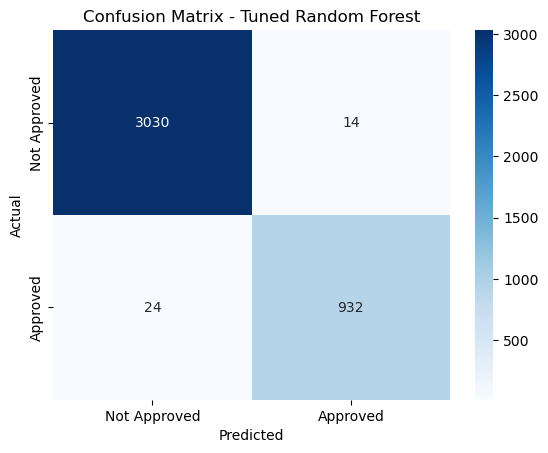

In [60]:
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

### Hyperparameter Tuning Results

GridSearchCV with 5-fold cross-validation was used to tune the Random Forest model. The search evaluated different combinations of the number of trees, tree depth, minimum samples required for splitting, and minimum samples required at leaf nodes.

The best configuration was:

- `n_estimators = 200`
- `max_depth = 20`
- `min_samples_split = 5`
- `min_samples_leaf = 1`

The best cross-validation ROC-AUC was 0.9994. The top parameter configurations produced very similar ROC-AUC scores, indicating that the model's performance was relatively stable across the strongest configurations.

On the held-out test set, the tuned model achieved 99.05% accuracy, 98.52% precision, 97.49% recall, and a ROC-AUC of 99.94%. The confusion matrix contained 14 false positives and 24 false negatives.

Using the defined business costs, the model produced an estimated business cost of $892,000 on the test set. This cost reflects the higher penalty assigned to false positives ($50,000) compared with false negatives ($8,000).

The results demonstrate how hyperparameter tuning can improve and validate model performance. However, the extremely high ROC-AUC and accuracy warrant additional investigation for potential data leakage or features that may contain information closely related to the loan approval outcome.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [61]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Not Approved", "Approved"]
))

              precision    recall  f1-score   support

Not Approved       0.99      1.00      0.99      3044
    Approved       0.99      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



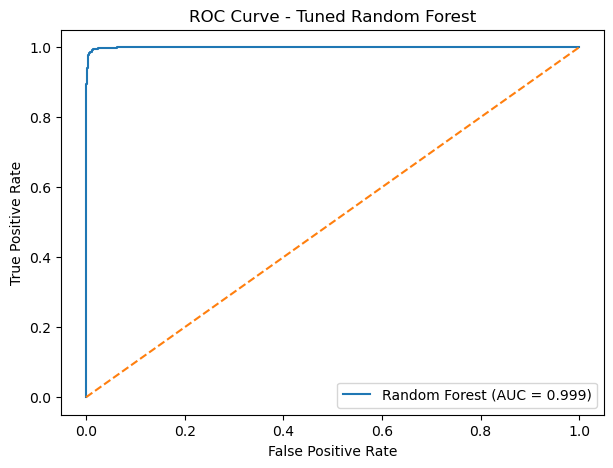

In [62]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_tuned):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()

In [63]:
def segment_performance(df_test, y_true, y_pred, segment_column):
    results = []
    
    for group in df_test[segment_column].dropna().unique():
        mask = df_test[segment_column] == group
        
        results.append({
            "Segment": group,
            "Count": mask.sum(),
            "Precision": precision_score(
                y_true[mask],
                y_pred[mask],
                zero_division=0
            ),
            "Recall": recall_score(
                y_true[mask],
                y_pred[mask],
                zero_division=0
            )
        })
    
    return pd.DataFrame(results)

In [64]:
segment_test = X_test.copy()
segment_test["Actual"] = y_test
segment_test["Predicted"] = y_pred_tuned

In [65]:
segment_performance(
    segment_test,
    segment_test["Actual"],
    segment_test["Predicted"],
    "EmploymentStatus"
)

,Segment,Count,Precision,Recall
0,Employed,3402,0.982989,0.981796
1,Unemployed,287,1.000000,0.980000
2,Self-Employed,311,1.000000,0.902439


In [66]:
segment_performance(
    segment_test,
    segment_test["Actual"],
    segment_test["Predicted"],
    "EducationLevel"
)

,Segment,Count,Precision,Recall
0,Associate,782,0.975309,0.975309
1,High School,1086,0.982036,0.987952
2,Bachelor,1163,0.990506,0.963077
3,Doctorate,156,1.000000,0.971014
4,Master,620,0.982906,0.982906


In [67]:
segment_performance(
    segment_test,
    segment_test["Actual"],
    segment_test["Predicted"],
    "BankruptcyHistory"
)

,Segment,Count,Precision,Recall
0,No,3777,0.984832,0.979526
1,Yes,223,1.000000,0.821429


### Segment Performance Analysis

The final Random Forest model was evaluated across employment status, education level, and bankruptcy history to identify potential differences in model performance between applicant groups.

Performance was consistently high across employment groups. However, recall for self-employed applicants was 90.24%, compared with 98.18% for employed applicants and 98.00% for unemployed applicants.

Performance across education levels was also strong, with recall ranging from 96.31% to 98.80%. The Doctorate group achieved 100% precision, although this group contained only 156 observations, so the result should be interpreted cautiously.

The largest difference was observed across bankruptcy history. Applicants with no bankruptcy history had 97.95% recall, while applicants with a bankruptcy history had 82.14% recall. This indicates that the model may perform differently across this segment and should be monitored carefully if the model is deployed.

These differences do not by themselves establish that the model is biased. Differences may be influenced by sample size, feature distributions, or relationships within the data. Additional fairness analysis would be required before deployment.

In [68]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
27,num__RiskScore,0.457464
26,num__TotalDebtToIncomeRatio,0.129346
19,num__MonthlyIncome,0.100269
1,num__AnnualIncome,0.098055
24,num__InterestRate,0.038130
4,num__LoanAmount,0.023755
22,num__NetWorth,0.016524
23,num__BaseInterestRate,0.014753
25,num__MonthlyLoanPayment,0.014372
17,num__TotalAssets,0.012832


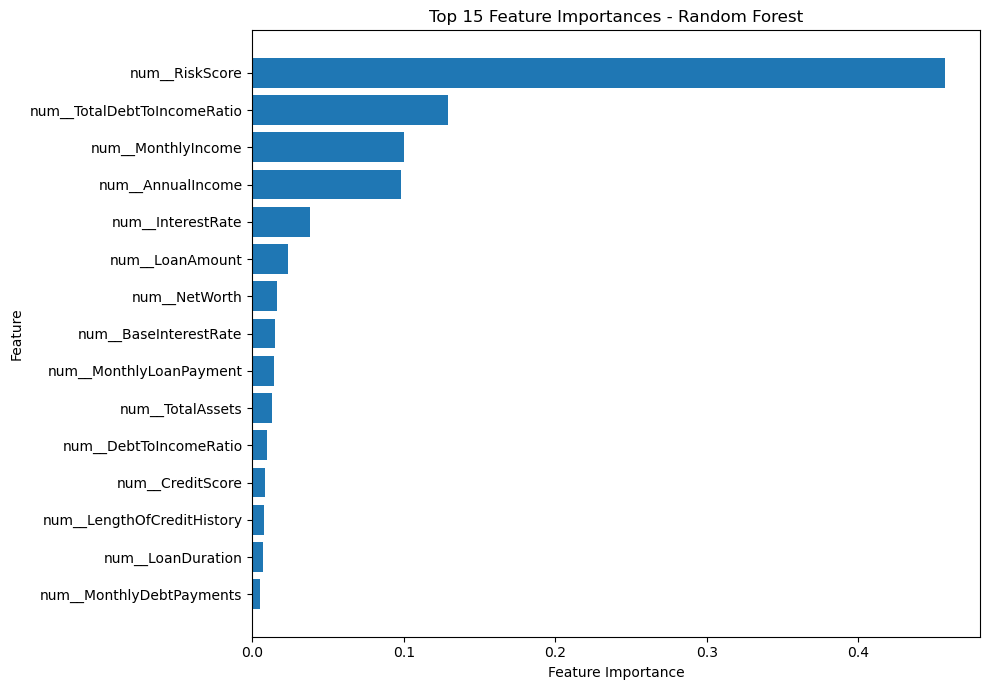

In [69]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

### Feature Importance Analysis

Feature importance was extracted from the tuned Random Forest model to identify the variables that contributed most strongly to its predictions.

`RiskScore` was by far the most important feature, accounting for approximately 45.75% of the model's total feature importance. This is consistent with the earlier correlation analysis, where `RiskScore` had the strongest correlation with `LoanApproved` (r = -0.766).

Other important features included `TotalDebtToIncomeRatio` (12.93%), `MonthlyIncome` (10.03%), `AnnualIncome` (9.81%), and `InterestRate` (3.81%). These variables are broadly related to an applicant's debt burden, income, and cost of borrowing.

The strong importance of `RiskScore` and the model's very high ROC-AUC of 0.9994 require additional validation before deployment. In particular, it should be confirmed that `RiskScore` is calculated using information available at the time of application and does not incorporate the loan approval decision or subsequent payment information. If it is based only on pre-application information, its high predictive importance may be legitimate. If it incorporates information that would not be available when making the approval decision, it could introduce target leakage.

Feature importance indicates predictive contribution rather than causation. Therefore, these results should not be interpreted as evidence that any individual feature directly causes loan approval or rejection.

## Step 10: Executive Summary and Business Recommendations

### Executive Summary

This project developed a machine learning classification model to support loan approval decisions for FinTech Innovations. The dataset contained 20,000 loan applications, with approximately 24% approved and 76% not approved. Because the target variable was imbalanced and false positives and false negatives had different financial consequences, model performance was evaluated using accuracy, precision, recall, ROC-AUC, and a business cost metric.

Three classification models were evaluated: Logistic Regression, Decision Tree, and Random Forest. A Random Forest model was selected for hyperparameter tuning because it can capture nonlinear relationships and interactions between applicant characteristics. GridSearchCV with 5-fold cross-validation was used to tune the model.

The selected Random Forest configuration used 200 trees, a maximum depth of 20, a minimum of 5 samples required to split an internal node, and a minimum of 1 sample required at a leaf node.

On the held-out test set, the tuned model achieved:

* **Accuracy:** 99.05%
* **Precision:** 98.52%
* **Recall:** 97.49%
* **ROC-AUC:** 99.94%
* **Business Cost:** $892,000
* **False Positives:** 14
* **False Negatives:** 24

The model therefore demonstrated strong predictive performance on the test data. However, the extremely high ROC-AUC and accuracy require additional validation before deployment.

### Key Predictive Factors

Feature importance from the Random Forest identified several variables that contributed strongly to the model's predictions.

The most important feature was `RiskScore`, which accounted for approximately 45.75% of the model's total feature importance. Other important features included:

* `TotalDebtToIncomeRatio`: 12.93%
* `MonthlyIncome`: 10.03%
* `AnnualIncome`: 9.81%
* `InterestRate`: 3.81%
* `LoanAmount`: 2.38%

These results indicate that the model relies heavily on measures related to applicant risk, income, debt burden, and loan characteristics.

Feature importance represents predictive contribution rather than causation. Therefore, these results should not be interpreted as evidence that a feature directly causes a loan to be approved or rejected.

### Segment Performance and Limitations

The model performed strongly across the evaluated applicant segments, but some differences were observed.

Self-employed applicants had a recall of 90.24%, compared with 98.18% for employed applicants and 98.00% for unemployed applicants. Applicants with a recorded bankruptcy history had a recall of 82.14%, compared with 97.95% for applicants without a bankruptcy history.

These differences do not by themselves demonstrate model bias. They may be influenced by sample size, feature distributions, or relationships within the training data. However, the differences should be monitored if the model is considered for deployment.

The `RiskScore` variable also requires particular attention. It had a correlation of -0.766 with the target and accounted for approximately 45.75% of Random Forest feature importance. Before deployment, FinTech Innovations should confirm that `RiskScore` is calculated exclusively from information available at the time of the loan application. If it incorporates the approval decision or information obtained after the application, it could introduce target leakage and artificially inflate model performance.

### Business Recommendations

1. **Use the model as decision support rather than fully automated approval.**
   The model can help loan officers identify applications that are likely to be approved or rejected, while maintaining human oversight for appropriate cases.

2. **Validate `RiskScore` before deployment.**
   The company should confirm how `RiskScore` is calculated and ensure that it does not contain information that would only become available after the approval decision.

3. **Validate the assumed business costs.**
   The current analysis assumes a cost of $50,000 for a false positive and $8,000 for a false negative. These assumptions should be compared with actual historical default losses and lost-profit estimates before being used for production decisions.

4. **Optimize the classification threshold.**
   The model currently uses the default classification threshold. Because false positives have a substantially higher assumed cost than false negatives, different probability thresholds should be evaluated to determine whether the overall business cost can be reduced.

5. **Monitor performance across applicant segments.**
   Precision and recall should be monitored across employment status, education level, bankruptcy history, and other relevant groups to identify meaningful performance differences after deployment.

6. **Perform ongoing model monitoring.**
   Model performance should be monitored over time for changes in applicant characteristics, approval patterns, and prediction quality. The model should be retrained or recalibrated when significant data or performance drift occurs.

### Potential Improvements

Future work could improve the analysis by:

* Testing the model after removing or replacing `RiskScore` to determine how much performance depends on this variable.
* Performing temporal or external validation on new loan applications.
* Tuning the classification threshold according to the company's actual financial costs.
* Calibrating predicted probabilities so that predicted approval probabilities better reflect observed outcomes.
* Conducting a formal fairness analysis using appropriate group-level metrics.
* Comparing the machine learning system against the existing manual approval process.
* Incorporating actual loan repayment or default outcomes into future modeling so that financial risk can be measured directly rather than inferred from the historical approval target.

### Final Recommendation

The tuned Random Forest demonstrated strong predictive performance on the available test data and shows potential as a decision-support tool for loan approval. However, the very high predictive performance, particularly
